In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Database se connection
conn = sqlite3.connect("../olist.db")

# Check karein saari tables properly exist karti hain ya nahi
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
print("Available Tables:")
print(tables)

Available Tables:
                   name
0                orders
1             customers
2           order_items
3              payments
4              products
5  category_translation
6               sellers
7               reviews
8           geolocation


In [3]:
orders_df = pd.read_sql_query("SELECT * FROM orders LIMIT 5;", conn)
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       5 non-null      str  
 1   customer_id                    5 non-null      str  
 2   order_status                   5 non-null      str  
 3   order_purchase_timestamp       5 non-null      str  
 4   order_approved_at              5 non-null      str  
 5   order_delivered_carrier_date   5 non-null      str  
 6   order_delivered_customer_date  5 non-null      str  
 7   order_estimated_delivery_date  5 non-null      str  
dtypes: str(8)
memory usage: 452.0 bytes


In [4]:
# 1. Poori orders table ko load karte hain
orders = pd.read_sql_query("SELECT * FROM orders;", conn)

# 2. String dates ko actual Datetime format me convert karte hain
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# 3. Check karte hain data types update hue ya nahi
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [5]:
# 1. Check karein orders ke status ka breakdown kya hai
print("--- Order Status Breakdown ---")
print(orders['order_status'].value_counts())

# 2. Delivered orders ke liye Delivery Time (Actual Delivery - Purchase Date) calculate karein
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# 3. Quick Stats on Delivery Time
print("\n--- Delivery Time (Days) Summary ---")
print(orders['delivery_days'].describe())

--- Order Status Breakdown ---
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

--- Delivery Time (Days) Summary ---
count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


  order_month  total_orders  item_revenue  total_freight  total_gross_revenue
0     2016-09             1        134.97           8.49               143.46
1     2016-10           265      40325.11        6165.55             46490.66
2     2016-12             1         10.90           8.72                19.62
3     2017-01           750     111798.36       15684.01            127482.37
4     2017-02          1653     234223.40       37015.92            271239.32
5     2017-03          2546     359198.85       55132.10            414330.95
6     2017-04          2303     340669.68       50142.72            390812.40
7     2017-05          3546     489338.25       77513.15            566851.40
8     2017-06          3135     421923.37       68127.00            490050.37
9     2017-07          3872     481604.52       84694.56            566299.08


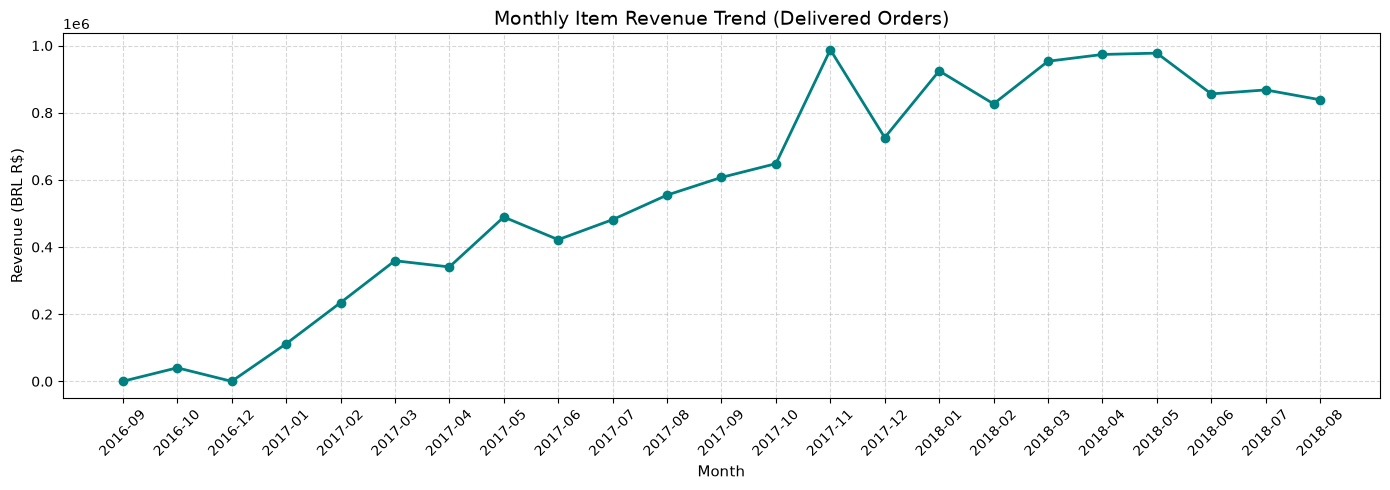

In [6]:
# 1. Orders aur Order Items ko join karke delivered orders ka revenue nikaalte hain
revenue_query = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(i.price), 2) AS item_revenue,
    ROUND(SUM(i.freight_value), 2) AS total_freight,
    ROUND(SUM(i.price + i.freight_value), 2) AS total_gross_revenue
FROM orders o
JOIN order_items i ON o.order_id = i.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

monthly_sales = pd.read_sql_query(revenue_query, conn)

# 2. Results preview
print(monthly_sales.head(10))

# 3. Monthly Sales ka simple line plot banate hain
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['order_month'], monthly_sales['item_revenue'], marker='o', color='teal', linewidth=2)
plt.title('Monthly Item Revenue Trend (Delivered Orders)', fontsize=14)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Revenue (BRL R$)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Top 10 Categories by Revenue ---
                category  total_orders  total_revenue
0          health_beauty          8647     1233131.72
1          watches_gifts          5495     1166176.98
2         bed_bath_table          9272     1023434.76
3         sports_leisure          7530      954852.55
4  computers_accessories          6530      888724.61
5        furniture_decor          6307      711927.69
6             housewares          5743      615628.69
7             cool_stuff          3559      610204.10
8                   auto          3810      578966.65
9                   toys          3804      471286.48


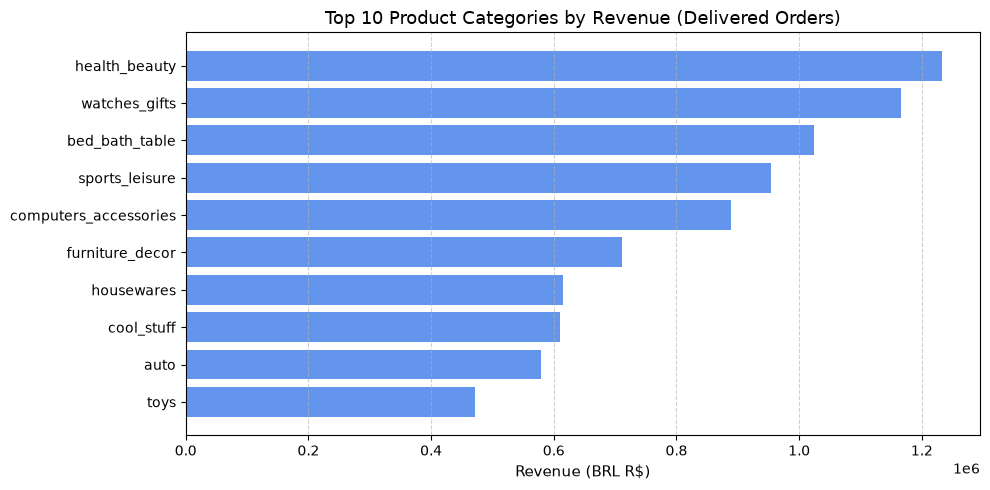

In [7]:
# Top 10 Product Categories by Revenue
top_categories_query = """
SELECT 
    COALESCE(t.product_category_name_english, p.product_category_name) AS category,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(i.price), 2) AS total_revenue
FROM orders o
JOIN order_items i ON o.order_id = i.order_id
JOIN products p ON i.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_categories_df = pd.read_sql_query(top_categories_query, conn)

# Table preview
print("--- Top 10 Categories by Revenue ---")
print(top_categories_df)

# Ek simple Horizontal Bar Chart banate hain
plt.figure(figsize=(10, 5))
plt.barh(top_categories_df['category'][::-1], top_categories_df['total_revenue'][::-1], color='cornflowerblue')
plt.title('Top 10 Product Categories by Revenue (Delivered Orders)', fontsize=13)
plt.xlabel('Revenue (BRL R$)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- Payment Method Breakdown ---
  payment_type  total_transactions  total_amount  avg_installments
0  credit_card               76795   12542084.19               3.5
1       boleto               19784    2869361.27               1.0
2      voucher                5775     379436.87               1.0
3   debit_card                1529     217989.79               1.0


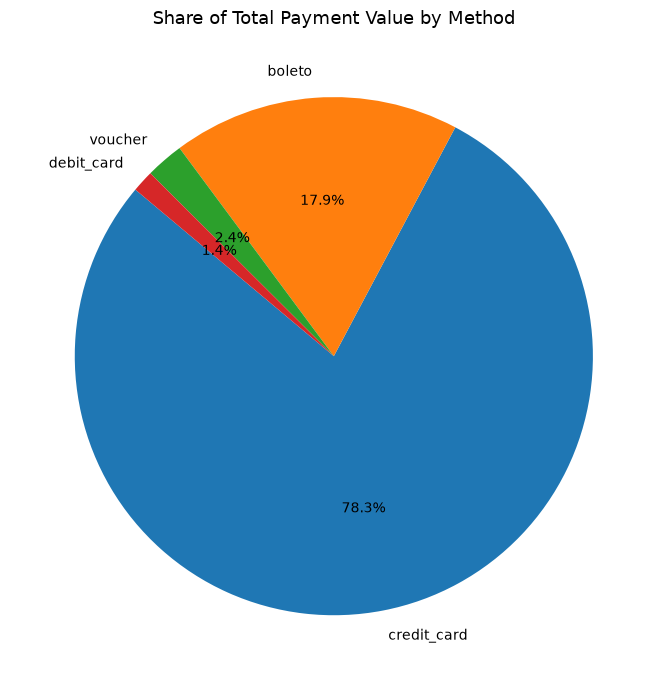

In [8]:
# 1. Payment Types ka breakdown
payment_type_query = """
SELECT 
    payment_type,
    COUNT(order_id) AS total_transactions,
    ROUND(SUM(payment_value), 2) AS total_amount,
    ROUND(AVG(payment_installments), 1) AS avg_installments
FROM payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY total_amount DESC;
"""

payment_df = pd.read_sql_query(payment_type_query, conn)
print("--- Payment Method Breakdown ---")
print(payment_df)

# 2. Credit Card Installments ka distribution check karte hain
installments_query = """
SELECT 
    payment_installments,
    COUNT(order_id) AS order_count
FROM payments
WHERE payment_type = 'credit_card'
GROUP BY payment_installments
ORDER BY payment_installments
LIMIT 12;
"""

installments_df = pd.read_sql_query(installments_query, conn)

# Donut Chart for Payment Types
plt.figure(figsize=(7, 7))
plt.pie(payment_df['total_amount'], labels=payment_df['payment_type'], autopct='%1.1f%%', startangle=140)
plt.title('Share of Total Payment Value by Method', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# 1. State-wise Average Delivery Time (Top 10 slowest vs Top 5 fastest states)
state_delivery_query = """
SELECT 
    c.customer_state,
    COUNT(o.order_id) AS total_orders,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)), 1) AS avg_delivery_days,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)), 1) AS avg_delay_vs_estimate
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC;
"""

state_df = pd.read_sql_query(state_delivery_query, conn)

print("--- Slowest 5 States (Longest Delivery Times) ---")
print(state_df.head(5))

print("\n--- Fastest 5 States (Quickest Delivery Times) ---")
print(state_df.tail(5))

# 2. On-Time vs Delayed Delivery ka Customer Rating par asar
delay_impact_query = """
SELECT 
    CASE 
        WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 'Delayed (Late)'
        ELSE 'On-Time / Early'
    END AS delivery_performance,
    COUNT(r.review_id) AS total_reviews,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_performance;
"""

impact_df = pd.read_sql_query(delay_impact_query, conn)
print("\n--- Impact of Delivery Delay on Customer Reviews ---")
print(impact_df)

--- Slowest 5 States (Longest Delivery Times) ---
  customer_state  total_orders  avg_delivery_days  avg_delay_vs_estimate
0             RR            41               29.4                  -16.6
1             AP            67               27.2                  -19.1
2             AM           145               26.4                  -18.9
3             AL           397               24.5                   -8.0
4             PA           946               23.8                  -13.4

--- Fastest 5 States (Quickest Delivery Times) ---
   customer_state  total_orders  avg_delivery_days  avg_delay_vs_estimate
22             SC          3546               15.0                  -10.8
23             DF          2080               13.0                  -11.3
24             PR          4923               12.0                  -12.6
25             MG         11354               12.0                  -12.5
26             SP         40494                8.8                  -10.4

--- Impact of D

In [10]:
# Reference Date: Dataset ke aakhri order date ke 1 din baad ki date
# (Taki recency days calculate ho sake)

rfm_query = """
WITH CustomerMetrics AS (
    SELECT 
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp) AS last_order_date,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(p.payment_value), 2) AS monetary
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN payments p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
MaxDate AS (
    SELECT DATE(MAX(order_purchase_timestamp), '+1 day') AS snapshot_date FROM orders
)
SELECT 
    cm.customer_unique_id,
    CAST(ROUND(julianday(md.snapshot_date) - julianday(cm.last_order_date)) AS INTEGER) AS recency_days,
    cm.frequency,
    cm.monetary
FROM CustomerMetrics cm
CROSS JOIN MaxDate md;
"""

rfm_df = pd.read_sql_query(rfm_query, conn)

print("--- RFM Raw Data Preview ---")
print(rfm_df.head())

print("\n--- Frequency Distribution (Kitne customers repeat buyers hain?) ---")
print(rfm_df['frequency'].value_counts().head(5))

--- RFM Raw Data Preview ---
                 customer_unique_id  recency_days  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2           161          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f           164          1     27.19
2  0000f46a3911fa3c0805444483337064           586          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078           370          1     43.62
4  0004aac84e0df4da2b147fca70cf8255           337          1    196.89

--- Frequency Distribution (Kitne customers repeat buyers hain?) ---
frequency
1    90556
2     2573
3      181
4       28
5        9
Name: count, dtype: int64


--- RFM Customer Segments Breakdown ---
              Segment  total_customers  avg_recency   avg_spend  total_revenue
0  At Risk (Slipping)            23163   326.384363  163.115592     3778246.46
1   Champions / Loyal             1379   162.026831  343.410022      473562.42
2      Lost Customers            23459   497.917345  163.676747     3839692.80
3     Recent / Active            45356   161.069561  161.631539     7330960.09


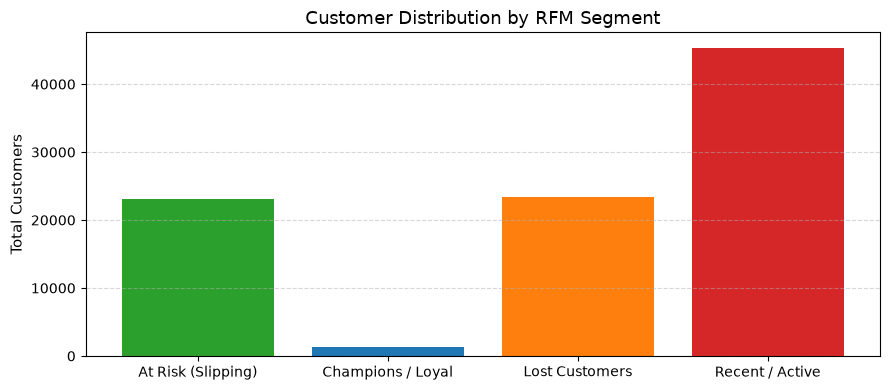

In [11]:
# 1. Quantiles ke through Recency aur Monetary ko 1 se 4 score dete hain
# (Recency me kam din = better score 4, isliye labels inverted hain)
rfm_df['R_Score'] = pd.qcut(rfm_df['recency_days'], q=4, labels=[4, 3, 2, 1])
rfm_df['M_Score'] = pd.qcut(rfm_df['monetary'], q=4, labels=[1, 2, 3, 4])

# Frequency mostly 1 hai, isliye rule-based define karenge:
# >1 order = High Frequency (Score 2), 1 order = Low Frequency (Score 1)
rfm_df['F_Score'] = rfm_df['frequency'].apply(lambda x: 2 if x > 1 else 1)

# 2. Customer Segmentation Logic
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 3 and f == 2 and m >= 3:
        return 'Champions / Loyal'
    elif r >= 3 and f == 1:
        return 'Recent / Active'
    elif r == 2:
        return 'At Risk (Slipping)'
    else:
        return 'Lost Customers'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

# 3. Segments Summary Table
segment_summary = rfm_df.groupby('Segment').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_spend=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()

print("--- RFM Customer Segments Breakdown ---")
print(segment_summary)

# 4. Bar chart of Segments
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.bar(segment_summary['Segment'], segment_summary['total_customers'], color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
plt.title('Customer Distribution by RFM Segment', fontsize=13)
plt.ylabel('Total Customers', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# Master dataset export karte hain Dashboard banane ke liye
export_query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    o.order_status,
    c.customer_unique_id,
    c.customer_state,
    c.customer_city,
    COALESCE(t.product_category_name_english, p.product_category_name) AS category,
    i.price,
    i.freight_value,
    pay.payment_type,
    pay.payment_installments,
    pay.payment_value,
    r.review_score,
    ROUND(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp), 1) AS actual_delivery_days,
    ROUND(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date), 1) AS delay_vs_estimate
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items i ON o.order_id = i.order_id
JOIN products p ON i.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
LEFT JOIN payments pay ON o.order_id = pay.order_id
LEFT JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered';
"""

print("Extracting consolidated data...")
master_df = pd.read_sql_query(export_query, conn)

# RFM Segment ko merge karte hain
master_df = master_df.merge(rfm_df[['customer_unique_id', 'Segment']], on='customer_unique_id', how='left')

# Clean CSV save karein
master_df.to_csv("../data/olist_dashboard_data.csv", index=False)
print(f"Export Complete! File saved: data/olist_dashboard_data.csv ({len(master_df):,} rows)")

Extracting consolidated data...
Export Complete! File saved: data/olist_dashboard_data.csv (115,723 rows)
